# Phase 4c — Cross-Dataset Zero-Shot Transfer (SPRSound)
**Project:** Robust Respiratory Sound Classification under Noise and Domain Shift using Audio Spectrogram Transformers

**Goal:** run your **frozen** Phase 3 winner, unmodified, on SPRSound -- a completely different respiratory sound dataset it has never seen. No fine-tuning happens here. This measures whether the model generalizes to a genuinely different patient population, recording setup, and (in SPRSound's case) a pediatric population rather than ICBHI's mixed adult/pediatric mix.

**NOTE:** SPRSound is not available on Kaggle dataset:
- GitHub mirror: `SJTU-YONGFU-RESEARCH-GRP/SPRSound`
- Once downloaded, upload it as your own **private Kaggle dataset**, then attach.

**The label-mapping :** SPRSound uses a different, more granular label set than ICBHI's 4 classes:
- SPRSound: Normal, Wheeze, Rhonchi, Stridor, Fine Crackle, Coarse Crackle, Wheeze+Crackle
- ICBHI (this project): Normal, Crackle, Wheeze, Both

**This notebook excludes cycles labeled Rhonchi or Stridor from evaluation** rather than force-mapping them into a misleading category.


In [1]:
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt
import librosa

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import ASTFeatureExtractor, ASTForAudioClassification
from tqdm.auto import tqdm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

plt.rcParams["figure.dpi"] = 110


## **1. Configuration**


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

SPRSOUND_DIR = Path("/kaggle/input/datasets/praveshsubba/sprsound-biocas2022-inter-subject-test-subset/SPRSound BioCAS2022 Inter-Subject Test Subset")   
SPRSOUND_AUDIO_DIR = SPRSOUND_DIR / "audio"                 
SPRSOUND_ANNOTATION_DIR = SPRSOUND_DIR / "annotations"     

# The winning checkpoint from Phase 3
AUGMENTATION_NOTEBOOK_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/03d-ast-augmentation-ablation"
)
BEST_CHECKPOINT_PATH = AUGMENTATION_NOTEBOOK_DIR / "checkpoints" / "ast_both_best.pt"

RESULTS_CSV = Path("/kaggle/working/results_phase4c.csv")
SPRSOUND_CACHE_DIR = Path("/kaggle/working/sprsound_waveform_cache")
SPRSOUND_CACHE_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["normal", "crackle", "wheeze", "both"]

TARGET_SR = 16000
LOWCUT = 50
HIGHCUT = 8000
TARGET_DURATION = 8.0

AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"
BATCH_SIZE = 8
NUM_WORKERS = 2

# SPRSound label -> ICBHI 4-class label. Rhonchi/Stridor map to None,
SPRSOUND_LABEL_MAP = {
    "normal": "normal",
    "fine crackle": "crackle",
    "coarse crackle": "crackle",
    "wheeze": "wheeze",
    "wheeze+crackle": "both",
    "wheeze & crackle": "both",
    "rhonchi": None,
    "stridor": None,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
assert DEVICE.type == "cuda", "Enable the GPU accelerator for this notebook before continuing."
assert BEST_CHECKPOINT_PATH.exists(), f"Checkpoint not found at {BEST_CHECKPOINT_PATH}"

Device: cuda


## **2. Parse the real SPRSound JSON format**

SPRSound stores event annotations as a list under `event_annotation`. `start` and `end` are milliseconds, so they must be divided by 1000 before slicing the audio.

In [3]:
def normalize_label(label):
    if label is None:
        return None
    return str(label).strip().lower()


def load_sprsound_annotations(sprsound_dir):
    rows = []
    bad_json = []
    no_events = []

    wav_by_stem = {p.stem: p for p in sprsound_dir.rglob("*.wav")} # find all wave files 
    json_files = sorted(sprsound_dir.rglob("*.json")) # all json files

    for ann_path in tqdm(json_files, desc="Processing JSON files"):
        stem = ann_path.stem

        if stem not in wav_by_stem:
            continue

        try:
            with open(ann_path, "r", encoding="utf-8") as f: # open the json file
                data = json.load(f)
        except Exception as e:
            bad_json.append((str(ann_path), str(e)))
            continue

        events = data.get("event_annotation", [])

        if not isinstance(events, list) or len(events) == 0: # if event is empty
            no_events.append(str(ann_path))
            continue

        audio_path = wav_by_stem[stem]

        for event in events:
            if not isinstance(event, dict):
                continue

            start_ms = event.get("start")
            end_ms = event.get("end")
            raw_label = event.get("type")

            if start_ms is None or end_ms is None or raw_label is None:
                continue

            try:
                start_sec = float(start_ms) / 1000.0
                end_sec = float(end_ms) / 1000.0
            except (TypeError, ValueError):
                continue

            if end_sec <= start_sec:
                continue

            rows.append({
                "audio_path": str(audio_path),
                "annotation_path": str(ann_path),
                "recording_id": stem,
                "start": start_sec,
                "end": end_sec,
                "sprsound_label": normalize_label(raw_label),
            })

    df = pd.DataFrame(rows)

    print(f"Valid event rows: {len(df)}")
    print(f"JSON files with invalid JSON: {len(bad_json)}")
    print(f"JSON files with no event annotations: {len(no_events)}")

    if len(bad_json) > 0:
        print("\nFirst invalid JSON:")
        print(bad_json[0])

    return df


sprsound_df = load_sprsound_annotations(SPRSOUND_DIR)

assert len(sprsound_df) > 0, "No event annotations were successfully parsed."

print("\nOriginal SPRSound event labels:")
print(sprsound_df["sprsound_label"].value_counts())


Processing JSON files:   0%|          | 0/355 [00:00<?, ?it/s]

Valid event rows: 1429
JSON files with invalid JSON: 0
JSON files with no event annotations: 8

Original SPRSound event labels:
sprsound_label
normal            1040
wheeze             305
fine crackle        80
coarse crackle       3
wheeze+crackle       1
Name: count, dtype: int64


In [4]:
sprsound_df.tail()

,audio_path,annotation_path,recording_id,start,end,sprsound_label
1424,/kaggle/input/datasets/praveshsubba/sprsound-b...,/kaggle/input/datasets/praveshsubba/sprsound-b...,65121853_1.5_0_p4_4246,2.703,3.326,wheeze
1425,/kaggle/input/datasets/praveshsubba/sprsound-b...,/kaggle/input/datasets/praveshsubba/sprsound-b...,65121853_1.5_0_p4_4246,3.994,4.583,wheeze
1426,/kaggle/input/datasets/praveshsubba/sprsound-b...,/kaggle/input/datasets/praveshsubba/sprsound-b...,65121853_1.5_0_p4_4246,5.250,5.897,wheeze
1427,/kaggle/input/datasets/praveshsubba/sprsound-b...,/kaggle/input/datasets/praveshsubba/sprsound-b...,65121853_1.5_0_p4_4246,11.947,12.618,wheeze
1428,/kaggle/input/datasets/praveshsubba/sprsound-b...,/kaggle/input/datasets/praveshsubba/sprsound-b...,65121853_1.5_0_p4_4246,13.236,13.938,wheeze


## **3. Map SPRSound events to the ICBHI four-class problem**

This is the critical label-alignment step. Fine/Coarse Crackle become `crackle`; Wheeze becomes `wheeze`; Wheeze+Crackle becomes `both`; Normal stays `normal`. Rhonchi and Stridor are excluded rather than incorrectly forcing them into an ICBHI class.

In [5]:
sprsound_df["label"] = sprsound_df["sprsound_label"].map(SPRSOUND_LABEL_MAP) # mapping between two labels

n_total_events = len(sprsound_df)
n_excluded = int(sprsound_df["label"].isna().sum())

excluded_labels = sorted(
    sprsound_df.loc[sprsound_df["label"].isna(), "sprsound_label"].dropna().unique()
)

sprsound_eval_df = (
    sprsound_df
    .dropna(subset=["label"]) # removes labels
    .reset_index(drop=True) # reset the index
)

print(f"Total parsed events       : {n_total_events}")
print(f"Excluded events           : {n_excluded}")
print(f"Excluded label types      : {excluded_labels}")
print(f"Evaluable mapped events   : {len(sprsound_eval_df)}")

print("\nMapped ICBHI-class distribution:")
print(sprsound_eval_df["label"].value_counts().reindex(LABELS, fill_value=0))

assert len(sprsound_eval_df) > 0, "No evaluable events remain after label mapping."


Total parsed events       : 1429
Excluded events           : 0
Excluded label types      : []
Evaluable mapped events   : 1429

Mapped ICBHI-class distribution:
label
normal     1040
crackle      83
wheeze      305
both          1
Name: count, dtype: int64


In [6]:
sprsound_eval_df.head()

,audio_path,annotation_path,recording_id,start,end,sprsound_label,label
0,/kaggle/input/datasets/praveshsubba/sprsound-b...,/kaggle/input/datasets/praveshsubba/sprsound-b...,40512331_8.1_1_p1_3548,0.017,1.623,normal,normal
1,/kaggle/input/datasets/praveshsubba/sprsound-b...,/kaggle/input/datasets/praveshsubba/sprsound-b...,40512331_8.1_1_p1_3548,1.623,2.878,normal,normal
2,/kaggle/input/datasets/praveshsubba/sprsound-b...,/kaggle/input/datasets/praveshsubba/sprsound-b...,40512331_8.1_1_p1_3552,4.878,6.847,normal,normal
3,/kaggle/input/datasets/praveshsubba/sprsound-b...,/kaggle/input/datasets/praveshsubba/sprsound-b...,40512331_8.1_1_p1_3552,8.007,9.194,normal,normal
4,/kaggle/input/datasets/praveshsubba/sprsound-b...,/kaggle/input/datasets/praveshsubba/sprsound-b...,40512331_8.1_1_p1_3552,6.847,8.007,normal,normal


## **4. Check that event timestamps are valid**

Before running the model, verify that each annotated event fits inside its corresponding WAV recording.

In [7]:
from functools import lru_cache

@lru_cache(maxsize=512) # remmembers duration
def get_audio_duration(audio_path):
    return librosa.get_duration(path=audio_path)


invalid_events = []

for row in sprsound_eval_df.itertuples(index=False):
    try:
        duration = get_audio_duration(row.audio_path)
    except Exception as e:
        invalid_events.append((row.recording_id, str(e)))
        continue

    if row.start < 0 or row.end > duration + 0.05:
        invalid_events.append(
            (row.recording_id, row.start, row.end, duration)
        )

print("Invalid event rows:", len(invalid_events))

if invalid_events:
    print("First invalid event:", invalid_events[0])

assert len(invalid_events) == 0, (
    "Some annotation timestamps are outside the corresponding WAV duration."
)


Invalid event rows: 0


## **5. Preprocessing — keep it aligned with the ICBHI model**

The frozen model must receive the same basic waveform representation used during Phase 3: mono audio -> band-pass filter -> 16 kHz -> 8-second fixed-length waveform -> AST feature extractor.

In [8]:
def bandpass_filter(signal, sr, lowcut=LOWCUT, highcut=HIGHCUT, order=5):
    nyquist = sr / 2.0
    highcut_safe = min(highcut, nyquist * 0.99)

    if lowcut >= highcut_safe:
        raise ValueError(
            f"Invalid bandpass for sr={sr}: "
            f"lowcut={lowcut}, highcut={highcut_safe}"
        )

    sos = butter(
        order,
        [lowcut, highcut_safe],
        btype="band",
        fs=sr,
        output="sos",
    )
    return sosfiltfilt(sos, signal).astype(np.float32)


def resample_audio(signal, orig_sr, target_sr=TARGET_SR):
    if orig_sr == target_sr:
        return signal.astype(np.float32)

    return librosa.resample(
        signal,
        orig_sr=orig_sr,
        target_sr=target_sr,
    ).astype(np.float32)


def pad_or_truncate(signal, sr, target_duration=TARGET_DURATION):
    target_length = int(target_duration * sr)

    if len(signal) == 0:
        raise ValueError("Empty respiratory event.")

    if len(signal) > target_length:
        start = (len(signal) - target_length) // 2
        return signal[start:start + target_length].astype(np.float32)

    if len(signal) < target_length:
        n_repeats = int(np.ceil(target_length / len(signal)))
        signal = np.tile(signal, n_repeats)

    return signal[:target_length].astype(np.float32)


def preprocess_waveform(audio_path, start, end):
    audio, sr = librosa.load(
        audio_path,
        sr=None,
        mono=True,
    )

    start_sample = max(0, int(round(start * sr)))
    end_sample = min(len(audio), int(round(end * sr)))

    cycle = audio[start_sample:end_sample]

    if len(cycle) == 0:
        raise ValueError(
            f"Empty event after slicing: {audio_path}, {start}, {end}"
        )

    cycle = bandpass_filter(cycle, sr)
    cycle = resample_audio(cycle, sr, TARGET_SR)
    cycle = pad_or_truncate(cycle, TARGET_SR, TARGET_DURATION)

    return cycle


def cache_sprsound_waveform(row):
    safe_start = f"{row['start']:.3f}".replace(".", "p")
    safe_end = f"{row['end']:.3f}".replace(".", "p")

    cache_name = (
        f"{row['recording_id']}_{safe_start}_{safe_end}.npy"
    )
    out_path = SPRSOUND_CACHE_DIR / cache_name

    if not out_path.exists():
        waveform = preprocess_waveform(
            row["audio_path"],
            row["start"],
            row["end"],
        )
        np.save(out_path, waveform)

    return str(out_path)


sprsound_eval_df["waveform_path"] = [
    cache_sprsound_waveform(row)
    for _, row in sprsound_eval_df.iterrows()
]

print("Cached events:", len(sprsound_eval_df))
print("Example cache:", sprsound_eval_df.iloc[0]["waveform_path"])


Cached events: 1429
Example cache: /kaggle/working/sprsound_waveform_cache/40512331_8.1_1_p1_3548_0p017_1p623.npy


## **6. Build the AST evaluation dataset**

In [9]:
feature_extractor = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)


class ASTEvalDataset(Dataset):
    def __init__(self, df, feature_extractor, label_list=LABELS):
        self.df = df.reset_index(drop=True)
        self.feature_extractor = feature_extractor
        self.label2idx = {
            label: i for i, label in enumerate(label_list)
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        waveform = np.load(row["waveform_path"]).astype(np.float32)

        inputs = self.feature_extractor(
            waveform,
            sampling_rate=TARGET_SR,
            return_tensors="pt",
        )

        x = inputs["input_values"].squeeze(0)
        y = torch.tensor(
            self.label2idx[row["label"]],
            dtype=torch.long,
        )

        return x, y


sprsound_ds = ASTEvalDataset(
    sprsound_eval_df,
    feature_extractor,
)

sprsound_loader = DataLoader(
    sprsound_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("Evaluation events:", len(sprsound_ds))


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Evaluation events: 1429


## **7. Load the frozen Phase 3 checkpoint**

In [10]:
id2label = {i: label for i, label in enumerate(LABELS)}
label2id = {label: i for i, label in enumerate(LABELS)}

model = ASTForAudioClassification.from_pretrained(
    AST_CHECKPOINT,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(DEVICE)


checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=DEVICE,
)

# Support common checkpoint formats.
if isinstance(checkpoint, dict):
    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint
else:
    state_dict = checkpoint

# Remove DataParallel prefix if it exists.
state_dict = {
    k.replace("module.", "", 1) if k.startswith("module.") else k: v
    for k, v in state_dict.items()
}

missing, unexpected = model.load_state_dict(
    state_dict,
    strict=False,
)

print("Checkpoint loaded.")
print("Missing keys    :", len(missing))
print("Unexpected keys :", len(unexpected))

if missing:
    print("First missing keys:", missing[:10])

if unexpected:
    print("First unexpected keys:", unexpected[:10])

model.eval()


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Checkpoint loaded.
Missing keys    : 0
Unexpected keys : 0


ASTForAudioClassification(
  (audio_spectrogram_transformer): ASTModel(
    (embeddings): ASTEmbeddings(
      (patch_embeddings): ASTPatchEmbeddings(
        (projection): Conv2d(1, 768, kernel_size=(16, 16), stride=(10, 10))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ASTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ASTLayer(
          (attention): ASTAttention(
            (attention): ASTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ASTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ASTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=T

## **8. ICBHI-style binary evaluation metric**

The model still predicts four classes. For the ICBHI-style score, `normal` is treated as normal and the other three mapped classes are treated as abnormal.

In [11]:
def icbhi_score(y_true_labels, y_pred_labels):
    y_true_labels = np.asarray(y_true_labels)
    y_pred_labels = np.asarray(y_pred_labels)

    true_abnormal = y_true_labels != "normal"
    pred_abnormal = y_pred_labels != "normal"

    normal_mask = ~true_abnormal
    abnormal_mask = true_abnormal

    specificity = (
        (~pred_abnormal[normal_mask]).sum()
        / max(normal_mask.sum(), 1)
    )

    sensitivity = (
        pred_abnormal[abnormal_mask].sum()
        / max(abnormal_mask.sum(), 1)
    )

    return {
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "icbhi_score": float((sensitivity + specificity) / 2),
        "n_normal": int(normal_mask.sum()),
        "n_abnormal": int(abnormal_mask.sum()),
    }


## **9. Zero-shot evaluation — no training**

ICBHI -> SPRSound ZERO-SHOT TRANSFER
Evaluated events : 1429
Sensitivity      : 61.70%
Specificity      : 88.65%
ICBHI Score      : 75.18%
Normal events    : 1040
Abnormal events  : 389

              precision    recall  f1-score   support

      Normal       0.86      0.89      0.87      1040
     Crackle       0.14      0.10      0.11        83
      Wheeze       0.76      0.73      0.75       305
        Both       0.00      0.00      0.00         1

    accuracy                           0.81      1429
   macro avg       0.44      0.43      0.43      1429
weighted avg       0.80      0.81      0.80      1429



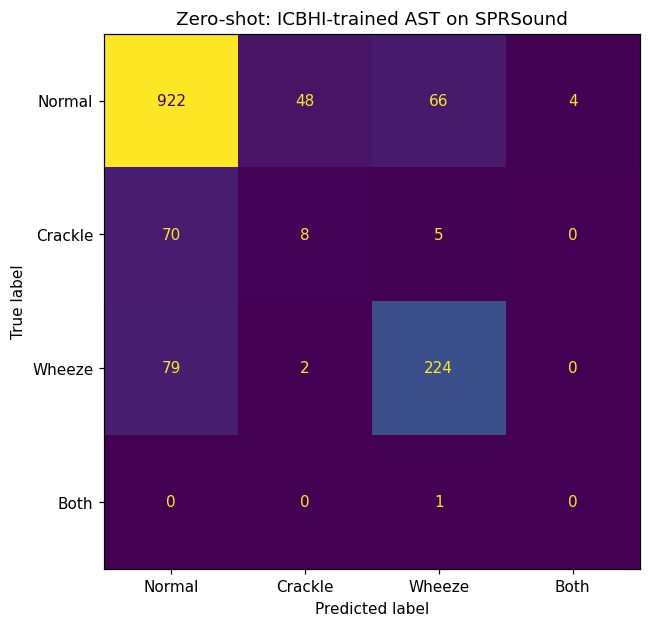

In [12]:
all_true = []
all_pred = []

with torch.no_grad():
    for xb, yb in sprsound_loader:
        xb = xb.to(DEVICE, non_blocking=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
        ):
            logits = model(input_values=xb).logits

        preds = logits.argmax(dim=1).cpu().numpy()

        all_true.extend(
            id2label[int(i)]
            for i in yb.numpy()
        )

        all_pred.extend(
            id2label[int(i)]
            for i in preds
        )


scores = icbhi_score(all_true, all_pred)

print("==============================================")
print("ICBHI -> SPRSound ZERO-SHOT TRANSFER")
print("==============================================")
print(f"Evaluated events : {len(all_true)}")
print(f"Sensitivity      : {scores['sensitivity'] * 100:.2f}%")
print(f"Specificity      : {scores['specificity'] * 100:.2f}%")
print(f"ICBHI Score      : {scores['icbhi_score'] * 100:.2f}%")
print(f"Normal events    : {scores['n_normal']}")
print(f"Abnormal events  : {scores['n_abnormal']}")
print()

print(
    classification_report(
        all_true,
        all_pred,
        labels=LABELS,
        target_names=["Normal", "Crackle", "Wheeze", "Both"],
        zero_division=0,
    )
)

cm = confusion_matrix(
    all_true,
    all_pred,
    labels=LABELS,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Crackle", "Wheeze", "Both"],
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
ax.set_title("Zero-shot: ICBHI-trained AST on SPRSound")
plt.tight_layout()
plt.show()


## **10. Save the cross-dataset result**

In [13]:
results_row = {
    "model": "AST (ICBHI-trained) -> SPRSound zero-shot",
    "dataset": "SPRSound BioCAS2022 matched annotated recordings",
    "n_recordings": int(sprsound_eval_df["recording_id"].nunique()),
    "n_events": len(sprsound_eval_df),
    "excluded_events": n_excluded,
    "excluded_labels": ", ".join(excluded_labels),
    "sensitivity": scores["sensitivity"],
    "specificity": scores["specificity"],
    "icbhi_score": scores["icbhi_score"],
}

pd.DataFrame([results_row]).to_csv(
    RESULTS_CSV,
    index=False,
)

print("Saved:", RESULTS_CSV)
print(pd.DataFrame([results_row]))


Saved: /kaggle/working/results_phase4c.csv
                                       model  \
0  AST (ICBHI-trained) -> SPRSound zero-shot   

                                            dataset  n_recordings  n_events  \
0  SPRSound BioCAS2022 matched annotated recordings           347      1429   

   excluded_events excluded_labels  sensitivity  specificity  icbhi_score  
0                0                     0.616967     0.886538     0.751753  


## **11. Deliverable checklist**

- Identical preprocessing pipeline to ICBHI (same filter, sample rate, padding) -- isolates dataset shift from preprocessing mismatch
- Rhonchi/Stridor cycles explicitly excluded, with the exclusion count reported, not silently dropped
- Zero-shot evaluation only -- no fine-tuning, no retraining

**Next:** `04d_noise_augmented_mitigation.ipynb`.